In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/passthrough_dataset.csv",
    parse_dates=["date"]
).set_index("date")

df = df.asfreq("ME")  # monthly frequency
print(df.columns)
df.head()

Index(['brent', 'wti', 'usdmyr', 'ron95', 'ron97', 'diesel', 'cpi_transport',
       'cpi_headline'],
      dtype='object')


,brent,wti,usdmyr,ron95,ron97,diesel,cpi_transport,cpi_headline
date,,,,,,,,
2020-01-31,63.645455,57.519048,4.080110,2.0800,2.5725,2.1800,115.0,122.4
2020-02-29,55.657000,50.542632,4.159900,2.0680,2.3780,2.1340,113.9,122.4
2020-03-31,32.011364,29.207727,4.298409,1.6325,1.9275,1.8150,104.0,120.9
2020-04-30,18.378500,16.547619,4.352486,1.2625,1.5625,1.4675,90.0,117.6
2020-05-31,29.378947,28.562500,4.340906,1.3240,1.6240,1.4740,90.9,117.9


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
brent,71.0,74.382561,19.951164,18.378500,65.108250,75.438000,84.088214,122.710952
wti,71.0,70.447573,18.803376,16.547619,62.250331,71.711818,80.651273,114.837143
usdmyr,71.0,4.365396,0.211758,4.037868,4.191023,4.330763,4.497888,4.772763
ron95,71.0,2.000007,0.202419,1.262500,2.050000,2.050000,2.050000,2.632500
ron97,71.0,3.100232,0.692697,1.562500,2.686500,3.242500,3.470000,4.786000
diesel,71.0,2.307134,0.444757,1.467500,2.150000,2.150000,2.486250,3.350000
cpi_transport,71.0,116.629577,7.613679,90.000000,114.600000,120.500000,121.550000,122.700000
cpi_headline,71.0,127.932394,5.247306,117.600000,123.000000,129.200000,132.900000,135.200000


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

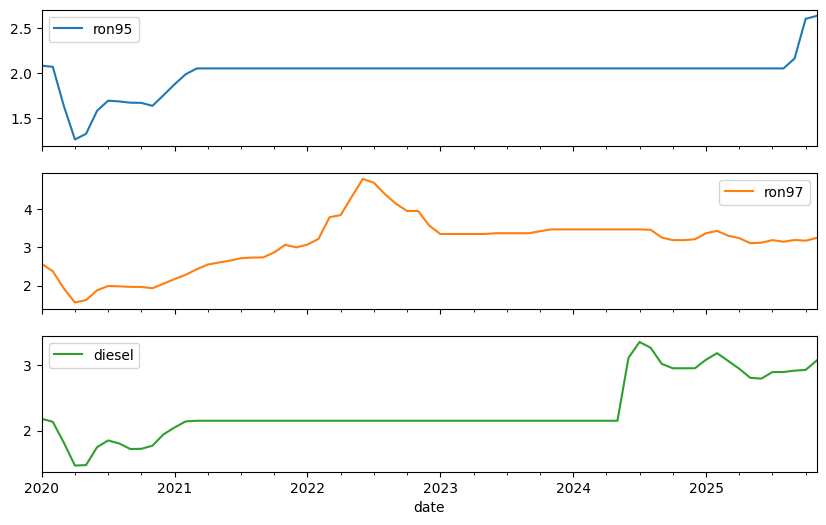

In [3]:
df[["ron95","ron97","diesel"]].plot(subplots=True, figsize=(10,6))

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

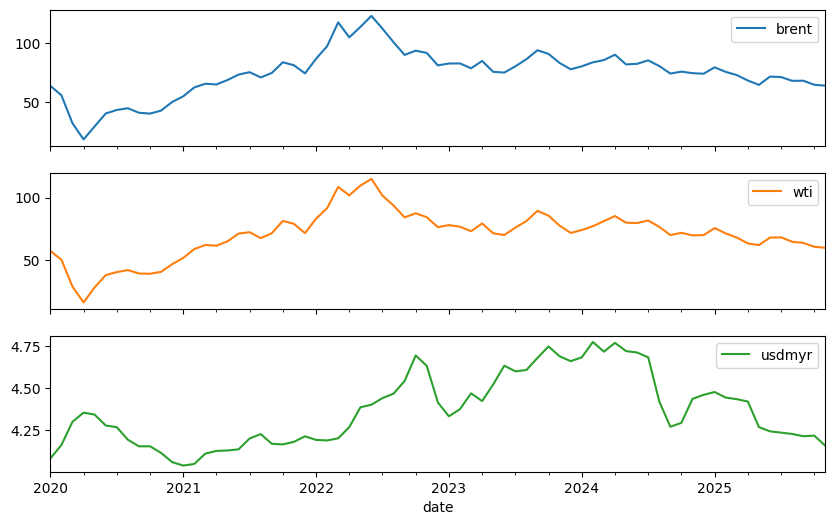

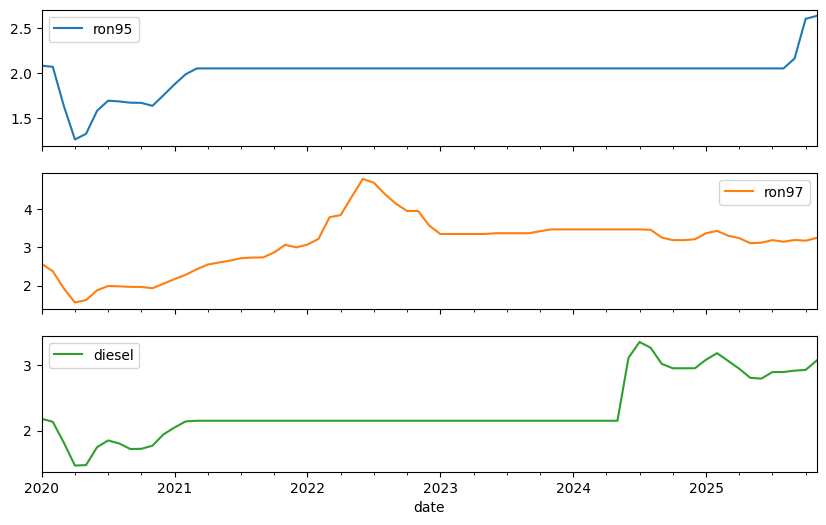

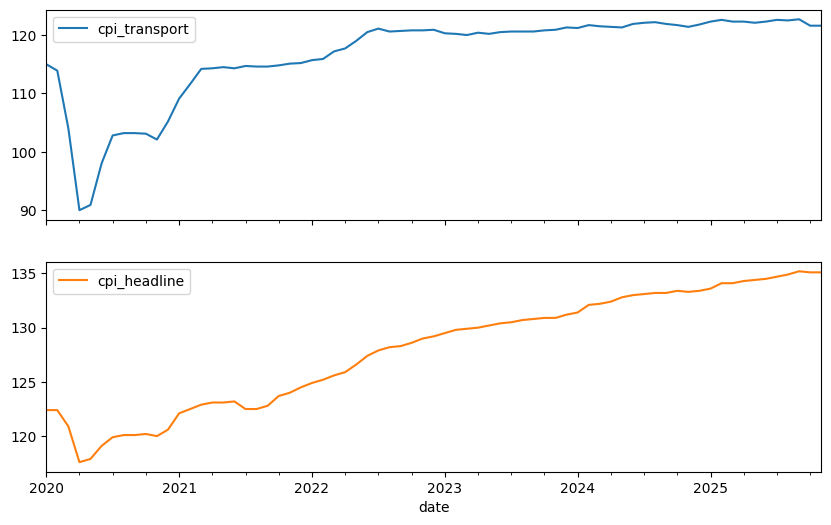

In [4]:
import matplotlib.pyplot as plt

df[["brent","wti","usdmyr"]].plot(subplots=True, figsize=(10,6))
df[["ron95","ron97","diesel"]].plot(subplots=True, figsize=(10,6))
df[["cpi_transport","cpi_headline"]].plot(subplots=True, figsize=(10,6))


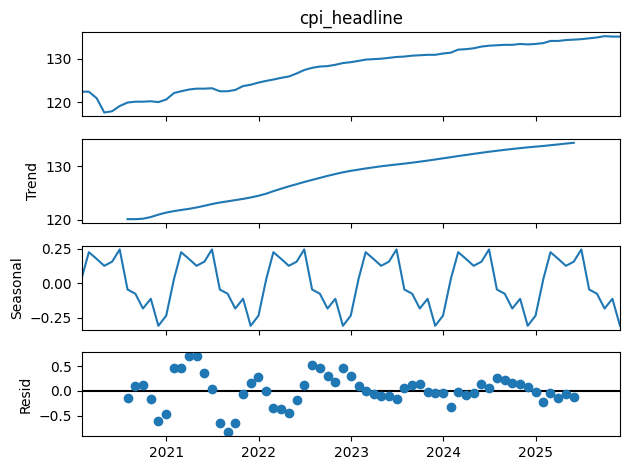

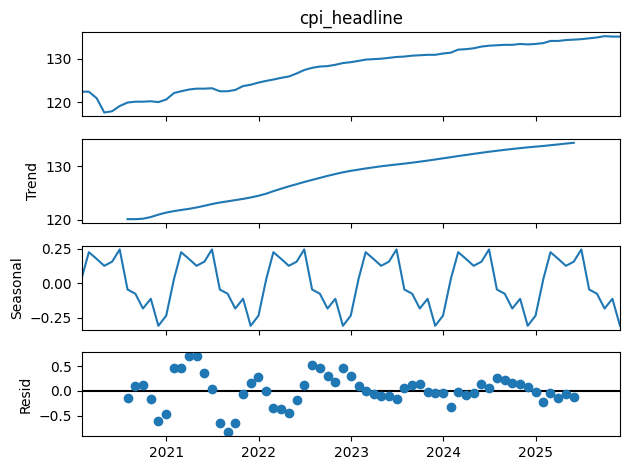

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_decompose(df["cpi_headline"], model="additive", period=12).plot()


In [6]:
from statsmodels.tsa.stattools import adfuller

for col in df.columns:
    p = adfuller(df[col].dropna())[1]
    print(col, round(p,4))


brent 0.5259
wti 0.2715
usdmyr 0.6158
ron95 0.0
ron97 0.3036
diesel 0.5196
cpi_transport 0.0
cpi_headline 0.9008


In [7]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Load your data
df = pd.read_csv("../data/processed/passthrough_dataset.csv", parse_dates=["date"]).set_index("date")

# List of variables to test
variables = ['brent', 'wti', 'usdmyr', 'ron95', 'ron97', 'diesel', 'cpi_transport', 'cpi_headline']

results = []

for var in variables:
    # Level Test
    adf_level = adfuller(df[var].dropna())
    # First Difference Test
    adf_diff = adfuller(df[var].diff().dropna())
    
    # Determine Integration Order (simplified rule: p<0.05 is stationary)
    if adf_level[1] < 0.05:
        order = "I(0)"
    elif adf_diff[1] < 0.05:
        order = "I(1)"
    else:
        order = "I(2+)"
        
    results.append({
        "Variable": var,
        "ADF Level (p-val)": round(adf_level[1], 4),
        "ADF 1st Diff (p-val)": round(adf_diff[1], 4),
        "Integration": order
    })

# Create the summary table
summary_table = pd.DataFrame(results)
print(summary_table)

        Variable  ADF Level (p-val)  ADF 1st Diff (p-val) Integration
0          brent             0.5259                0.0000        I(1)
1            wti             0.2715                0.0000        I(1)
2         usdmyr             0.6158                0.0000        I(1)
3          ron95             0.0000                0.0029        I(0)
4          ron97             0.3036                0.0000        I(1)
5         diesel             0.5196                0.0000        I(1)
6  cpi_transport             0.0000                0.0000        I(0)
7   cpi_headline             0.9008                0.0000        I(1)


Defaulting to user installation because normal site-packages is not writeable


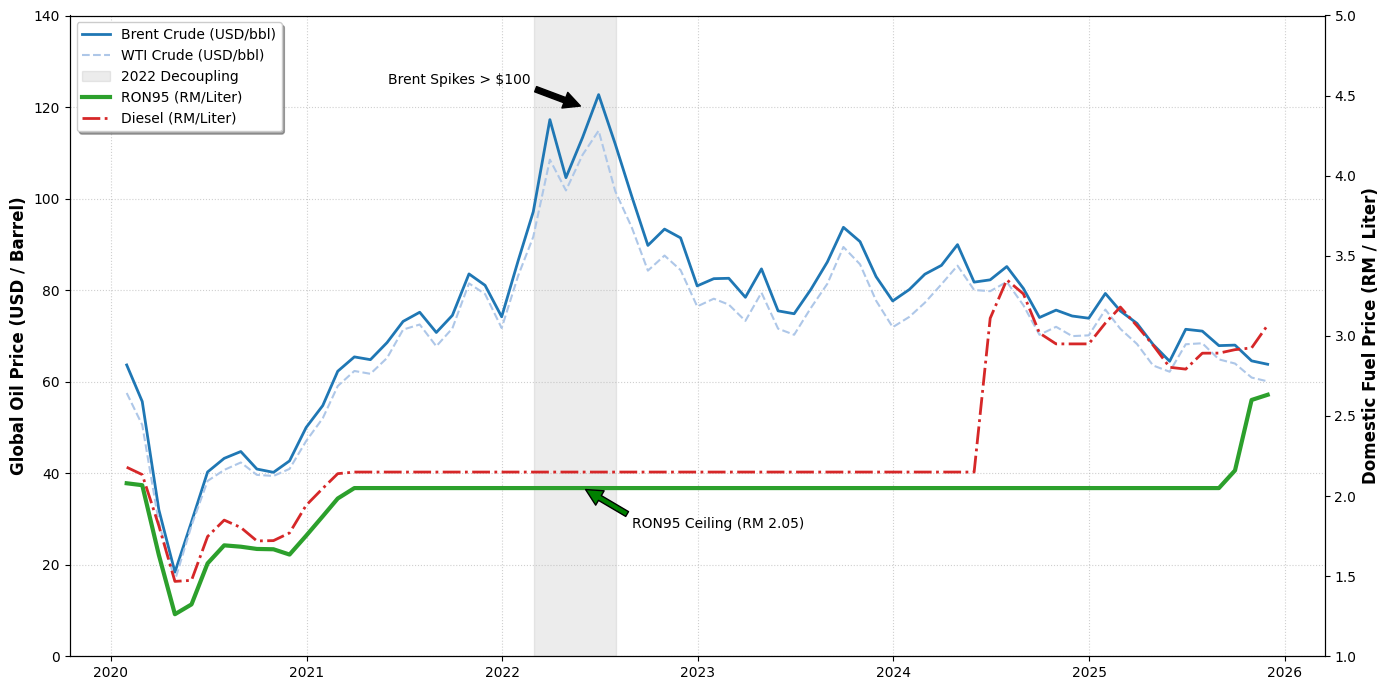

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

!pip install seaborn
import seaborn as sns

# Ensure the date index is set correctly
if 'date' in df.columns:
    df = df.set_index('date')

# Create the figure and primary axis (Left: Global Oil)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Global Benchmarks on Left Axis
color_brent = '#1f77b4'  # Blue
color_wti = '#aec7e8'    # Light Blue
ax1.plot(df.index, df['brent'], label='Brent Crude (USD/bbl)', color=color_brent, linewidth=2)
ax1.plot(df.index, df['wti'], label='WTI Crude (USD/bbl)', color=color_wti, linestyle='--', linewidth=1.5)
ax1.set_ylabel('Global Oil Price (USD / Barrel)', color='black', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 140)  # Adjust limit to frame the data well

# Create secondary axis (Right: Domestic Fuel)
ax2 = ax1.twinx()
color_ron95 = '#2ca02c'   # Green
color_diesel = '#d62728'  # Red
ax2.plot(df.index, df['ron95'], label='RON95 (RM/Liter)', color=color_ron95, linewidth=3)
ax2.plot(df.index, df['diesel'], label='Diesel (RM/Liter)', color=color_diesel, linewidth=2, linestyle='-.')
ax2.set_ylabel('Domestic Fuel Price (RM / Liter)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(1.0, 5.0)    # Adjust limit to frame the data well

# Highlight the 2022 Decoupling
# (Adjust dates slightly if your data index differs)
decoupling_start = pd.Timestamp('2022-03-01')
decoupling_end = pd.Timestamp('2022-08-01')
ax1.axvspan(decoupling_start, decoupling_end, color='gray', alpha=0.15, label='2022 Decoupling')

# Annotations
ax1.annotate('Brent Spikes > $100', 
             xy=(pd.Timestamp('2022-06-01'), 120), 
             xytext=(pd.Timestamp('2021-06-01'), 125),
             arrowprops=dict(facecolor='black', shrink=0.05))

ax2.annotate('RON95 Ceiling (RM 2.05)', 
             xy=(pd.Timestamp('2022-06-01'), 2.05), 
             xytext=(pd.Timestamp('2022-09-01'), 1.8),
             arrowprops=dict(facecolor='green', shrink=0.05))

# Formatting

ax1.grid(True, which='major', linestyle=':', alpha=0.6)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()